# Task 3 — Part A: Images as Tensors

How does PyTorch represent an image? We look at MNIST and CIFAR-10, the channel-first `(C, H, W)` convention, pixel statistics, and how a `DataLoader` batches images.


In [1]:
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

DATA_ROOT = r'C:/Users/SSM11011/Documents/SoC/task3/data'
print('torch', torch.__version__, '| torchvision', torchvision.__version__)


torch 2.12.1+cpu | torchvision 0.27.1+cpu


## MNIST — 28x28 grayscale handwritten digits

In [2]:
mnist = torchvision.datasets.MNIST(DATA_ROOT, train=True, download=True,
                                   transform=T.ToTensor())
img, label = mnist[0]
print('single image shape (C, H, W):', tuple(img.shape), '| label:', label)
print('C=1 because MNIST is grayscale; natural RGB images have C=3.')


single image shape (C, H, W): (1, 28, 28) | label: 5
C=1 because MNIST is grayscale; natural RGB images have C=3.


### Visualize the first 16 images

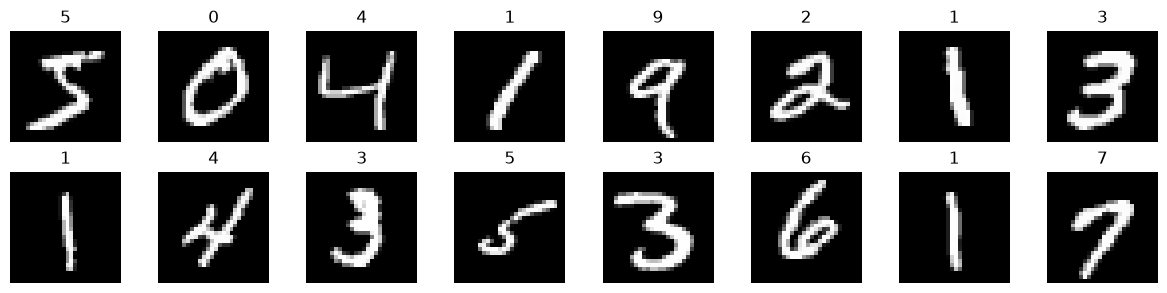

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    img, label = mnist[i]
    ax.imshow(img.squeeze(), cmap='gray')  # squeeze drops the channel dim for display
    ax.set_title(str(label)); ax.axis('off')
plt.tight_layout(); plt.show()


### Pixel statistics (MNIST is already in [0, 1])

In [4]:
img, _ = mnist[0]
print(f'min={img.min():.4f}  max={img.max():.4f}  mean={img.mean():.4f}')
print('Real photographs usually need standardization (subtract mean, divide by std).')


min=0.0000  max=1.0000  mean=0.1377
Real photographs usually need standardization (subtract mean, divide by std).


## CIFAR-10 — 32x32 color images, 10 classes

In [5]:
CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
cifar = torchvision.datasets.CIFAR10(DATA_ROOT, train=True, download=True,
                                     transform=T.ToTensor())
img, label = cifar[0]
print('single image shape (C, H, W):', tuple(img.shape), '| class:', CLASSES[label])
print('C=3 (RGB), H=W=32.')


single image shape (C, H, W): (3, 32, 32) | class: frog
C=3 (RGB), H=W=32.


C:\Users\SSM11011\Documents\SoC\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Visualize 16 CIFAR-10 images with class labels

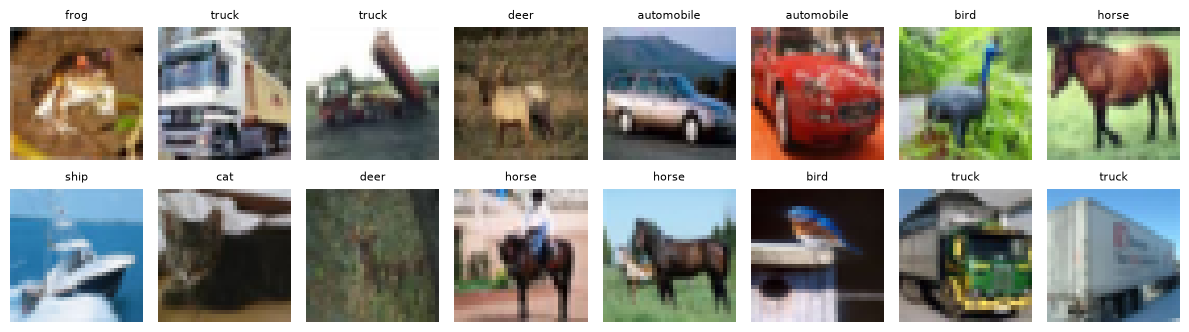

In [6]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i, ax in enumerate(axes.flat):
    img, label = cifar[i]
    # permute (C, H, W) -> (H, W, C) for matplotlib, which expects channels last.
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(CLASSES[label], fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()


## DataLoader — batching with batch size 64

In [7]:
loader = DataLoader(cifar, batch_size=64, shuffle=True, num_workers=0)
x, y = next(iter(loader))
print('batch images x shape:', tuple(x.shape))   # (64, 3, 32, 32)
print('batch labels y shape:', tuple(y.shape))   # (64,)
print('x dtype:', x.dtype, '| y dtype:', y.dtype)


batch images x shape: (64, 3, 32, 32)
batch labels y shape: (64,)
x dtype: torch.float32 | y dtype: torch.int64


---
**Takeaways.** PyTorch images are channel-first `(C, H, W)`; matplotlib and most image libraries are channel-last `(H, W, C)`, so we `permute` before `imshow`. A batch from a `DataLoader` stacks images into `(B, C, H, W)` with integer labels `(B,)`.
